<a href="https://colab.research.google.com/github/u9828057/Python_Practice/blob/main/Matplotlib/Python_%E6%9A%91%E5%81%87%E7%B7%B4%E7%BF%92_08_20%3A%E3%80%90Matplotlib%E3%80%91K_%E7%B7%9A%E5%9C%96%E3%80%81%E8%A0%9F%E7%87%AD%E5%9C%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#=========================================
# --- Colab 畫圖中文顯示起手式 ---
#=========================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 下載微軟正黑體 (或是 Noto 繁體中文)
!wget -q -O NotoSansTC-Regular.otf \
https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf
fm.fontManager.addfont('NotoSansTC-Regular.otf')
plt.rc('font', family='Noto Sans CJK TC')
plt.rcParams['axes.unicode_minus'] = False
# --------------------------------

print("環境設定完成！可以開始畫圖了！")

環境設定完成！可以開始畫圖了！


--------(Matplotlib: K 線圖、蠟燭圖)--------



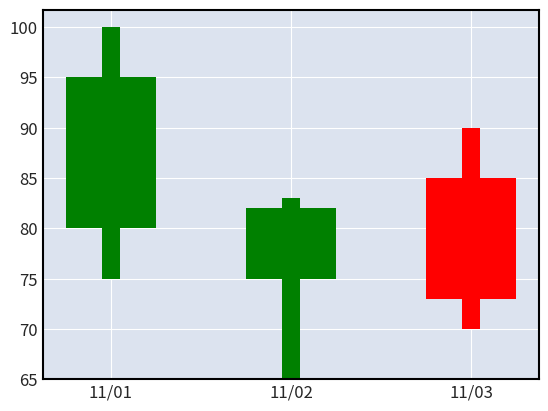


--------(從 CSV 格式載入資料，並繪製 K 線圖)--------

標頭: ['日期', '開盤', '收盤', '最高', '最低']
{'日期': '11/1', '開盤': '50', '收盤': '60', '最高': '65', '最低': '48'}
{'日期': '11/2', '開盤': '65', '收盤': '70', '最高': '80', '最低': '60'}
{'日期': '11/3', '開盤': '68', '收盤': '77', '最高': '80', '最低': '65'}
{'日期': '11/4', '開盤': '75', '收盤': '68', '最高': '76', '最低': '60'}
{'日期': '11/5', '開盤': '68', '收盤': '72', '最高': '75', '最低': '66'}
{'日期': '11/6', '開盤': '73', '收盤': '80', '最高': '85', '最低': '71'}
{'日期': '11/7', '開盤': '78', '收盤': '86', '最高': '90', '最低': '73'}
{'日期': '11/8', '開盤': '88', '收盤': '95', '最高': '98', '最低': '85'}
{'日期': '11/9', '開盤': '92', '收盤': '82', '最高': '92', '最低': '78'}
{'日期': '11/10', '開盤': '80', '收盤': '73', '最高': '81', '最低': '68'}


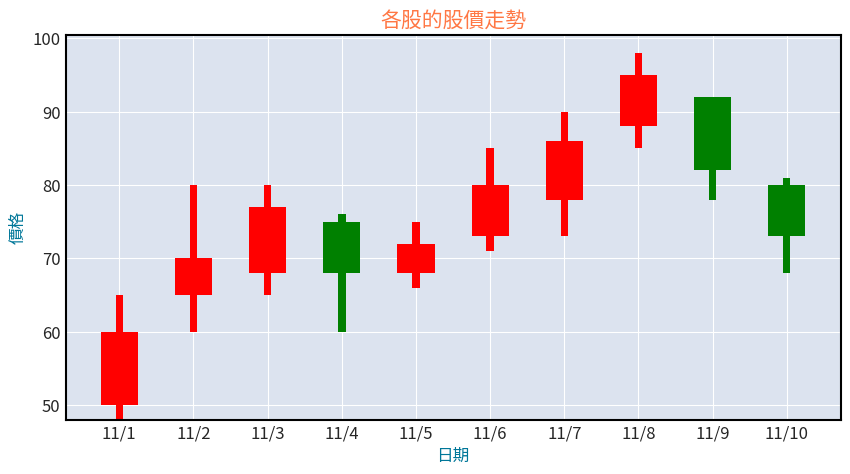

In [ ]:
import matplotlib.pyplot as plt
print("--------(Matplotlib: K 線圖、蠟燭圖)--------\n")

# 實際操作: 熟悉 K 線圖、蠟燭圖的操作

"""
  範例資料:
   日期   價格
   11/01  開盤 95, 收盤 80, 最高 100, 最低 75
   11/02  開盤 82, 收盤 75, 最高 83, 最低 65
   11/03  開盤 73, 收盤 85, 最高 90, 最低 70
"""

# 根據範例資料畫出基本的 K 線圖

# 11/01 陰陽線、影線
plt.bar("11/01", 15, bottom=80, width=0.5, color="green")  # 陰線
plt.bar("11/01", 25, bottom=75, width=0.1, color="green")  # 影線

# 11/02 陰陽線、影線
plt.bar("11/02", 7, bottom=75, width=0.5, color="green")  # 陰線
plt.bar("11/02", 18, bottom=65, width=0.1, color="green")  # 影線

# 11/03 陰陽線、影線
plt.bar("11/03", 12, bottom=73, width=0.5, color="red")  # 陽線
plt.bar("11/03", 20, bottom=70, width=0.1, color="red")  # 影線

plt.show()

#-------------------------------------------------------------

# 從 CSV 格式的檔案載入資料，並繪製 K 線圖
import csv
print("\n--------(從 CSV 格式載入資料，並繪製 K 線圖)--------\n")

# 1. 準備 CSV 資料數據
with open("candlestick-chart-data.csv", mode="w", encoding="utf-8",
      newline=""
     ) as file:
  w = csv.writer(file)
  w.writerow(["日期", "開盤", "收盤", "最高", "最低"])
  w.writerow(["11/1", 50, 60, 65, 48])
  w.writerow(["11/2", 65, 70, 80, 60])
  w.writerow(["11/3", 68, 77, 80, 65])
  w.writerow(["11/4", 75, 68, 76, 60])
  w.writerow(["11/5", 68, 72, 75, 66])
  w.writerow(["11/6", 73, 80, 85, 71])
  w.writerow(["11/7", 78, 86, 90, 73])
  w.writerow(["11/8", 88, 95, 98, 85])
  w.writerow(["11/9", 92, 82, 92, 78])
  w.writerow(["11/10", 80, 73, 81, 68])

# 2. 讀取資料
with open("candlestick-chart-data.csv", mode="r", encoding="utf-8",
      newline=""
     ) as file:
  r = csv.DictReader(file)
  header = r.fieldnames
  print(f"標頭: {header}")  # 讀取標題

  plt.figure(figsize=(10, 5))

  for row in r:
    print(f"{row}")
    date = (row["日期"])
    open_p = int(row["開盤"])
    highest = int(row["最高"])
    lowest = int(row["最低"])
    close_p = int(row["收盤"])

    # 決定陽線(上漲)或是陰線(下跌)
    if close_p > open_p:
      color="red"
    elif close_p < open_p:
      color="green"
    else:
      color="black"

    # 3. 繪製陰陽線
    plt.bar(date, abs(close_p - open_p),
        bottom=min(open_p, close_p), width=0.5, color=color
        )
    # 4. 繪製影線
    plt.bar(date, (highest - lowest),
        bottom=lowest, width=0.1, color=color
        )

  # 5. 完善圖表資訊
  plt.title("各股的股價走勢", fontsize=15, color="#FF7744")
  plt.xlabel("日期", fontsize=12, fontweight="bold", color="#007799")
  plt.ylabel("價格", fontsize=12, fontweight="bold", color="#007799")

  # 6. 顯示圖片
  plt.show()








#===========================================
# K 線圖、蠟燭圖 (Candlestick Chart)
# X 橫軸代表日期，Y 軸代表價格
#===========================================

# 每一個日期有 4 個價格
# 開盤價、收盤價 → 陰陽線
# 最高價、最低價 → 影線

# 顏色代表陰陽線、漲跌
# 陽線代表漲: 收盤價高於開盤價
# 陰線代表跌: 收盤價低於開盤價

#================================================
# Matplotlib K 線圖、蠟燭圖: 資料點的呈現
# 使用長條圖推疊出 K 線圖
#================================================

# K 線圖並非獨立的功能
# 使用長條圖的多次繪圖來完成

# 資料點範例如下:
# 日期: 10/15
# 價格: 開盤:85, 收盤:80, 最高:88, 最低:78
# 程式碼:
"""
plt.bar(        # 同一個日期，先畫陰陽線，比較寬胖
    "10/15", 5,  # 長條的高度為: 開收價相減
    bottom=80, width=0.5, color="green"
)
"""

_="""
plt.bar(         # 同一個日期，再繪製影線，比較細瘦
    "10/15", 10,  # 長條的高度為: 高低價相減
    bottom=78, width=0.1, color="green"
)
"""

#=======================
# 圖表的標題
# 使用 title 方法
#=======================

# 設定圖表標題
# 程式碼:
"""
plt.bar(
    "10/15", 5,
    bottom=80, width=0.5, color="green"
)
"""

_="""
plt.bar(
    "10/15", 10,
    bottom=78, width=0.1, color="green"
)
"""
# plt.title("圖表的標題")

#====================================
# 軸線的標題
# 使用 xlabel 與 ylabel 方法
#====================================

# 設定軸線標題
# 程式碼:
"""
plt.bar(
    "10/15", 5,
    bottom=80, width=0.5, color="green"
)
"""

_="""
plt.bar(
    "10/15", 10,
    bottom=78, width=0.1, color="green"
)
"""
# plt.xlabel("X 軸的標題")
# plt.ylabel("Y 軸的標題")


# 演練目標
# 熟悉 K 線圖的操作
# 繪製 X 軸為日期、Y 軸代表開盤、收盤、最高、最低四個價格的 K 線圖
# 載入 CSV 格式的檔案資料，繪製 K 線圖並加上適當的標示


In [ ]:
!pip install mplfinance

--------(Matplotlib: K 線圖、蠟燭圖)--------

      【查看轉換後的 DataFrame 結構】
            Open  High  Low  Close  Volume
Date                                      
2026-08-17   100   108   98    105    1500
2026-08-18   105   106  101    102    1200
2026-08-19   102   104   96     98    1800
2026-08-20    98   104   97    103    1600
2026-08-21   103   110  102    108    2000



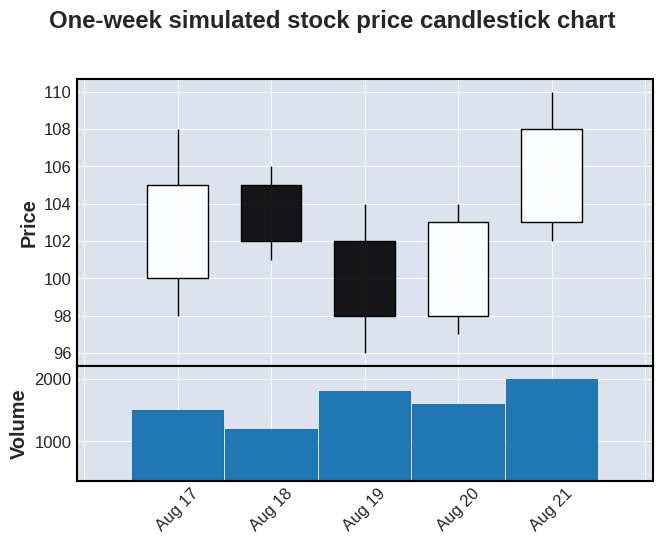

In [ ]:
import pandas as pd
import mplfinance as mpf
print("--------(Matplotlib: K 線圖、蠟燭圖)--------\n")

# 1. 準備數據 (須遵守 mplfinance 嚴格的資料格式)

# 模擬 5 天的股市數據
data = {
    "Date": ["2026-08-17", "2026-08-18", "2026-08-19",
         "2026-08-20", "2026-08-21"],
    "Open": [100, 105, 102, 98, 103],
    "High": [108, 106, 104, 104, 110],
    "Low": [98, 101, 96, 97, 102],
    "Close": [105, 102, 98, 103, 108],
    "Volume": [1500, 1200, 1800, 1600, 2000]  #交易量 (可選)
}

# 2. 將資料轉換為 Pandas DataFrame
df = pd.DataFrame(data)

# 3. 將 "Date" 欄位轉換為時間格式，並設定為索引 (Index)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
print(f"{' '*6}【查看轉換後的 DataFrame 結構】\n{df}\n")

# 4. 繪製 K 線圖

# §補充資料
# type="candle": 指定畫 K 線圖 (蠟燭圖)
# title: 圖表標題
# volume=True: 在下方自動加上交易量的長條圖
mpf.plot(df, type="candle",
     title="One-week simulated stock price candlestick chart",
     volume=True
    )








#===============================================
# §補充技巧: Pandas 時間序列資料處理核心
#===============================================

#---------------------------------------------
# 1. pd.to_datetime(): 賦予字串時間意義
#---------------------------------------------
# [用途]: 將純文字格式的日期 (例如: '2026-08-17') 轉換為電腦具備時間邏輯的 Timestamp 物件
# [場景]: 處理 CSV 載入的日期時間時，第一步必須做的標準動作

#-----------------------------------------------------------
# 2. df.set_index(欄位名稱， inplace=True): 設定索引
#-----------------------------------------------------------
# [用途]: 將某個資料欄位「釘」到表格最左側，取代原本的 0, 1, 2, 3 流水號，成為資料表的主鍵 (Index)
# [參數 inplace=True]: Pandas 的重要機制，代表「直接在原表格上進行修改」，而不是產生一張新表

# mplfinance 繪圖時，會自動抓取 DataFrame 的 Index 作為 X 軸
# 因此必須將「時間欄位」設定為 Index，才能畫出正確的時間序列圖


#=======================================================
# §補充觀念：K 線圖 (蠟燭圖) 核心知識與主流工具
#=======================================================

#-----------------------------------
# 1. K 線圖的核心觀念 (OHLC)
#-----------------------------------
# 要畫出一根完整的 K 線，必須準備四個關鍵數據，稱為 OHLC：
# [O] Open  (開盤價): 該時間週期內的「第一筆成交價」
# [H] High  (最高價): 該時間週期內的「最高價格」
# [L] Low  (最低價): 該時間週期內的「最低價格」
# [C] Close (收盤價): 該時間週期內的「最後一筆成交價」

# [視覺結構]:
# - 實體 (Body) : 由「開盤價」與「收盤價」組成的粗體方塊 (決定陰陽線與顏色)
# - 影線 (Shadow) : 上下兩端細長的線，分別延伸至「最高價」與「最低價」

#----------------------------------------------------
# 2. 現代主流繪圖工具與資料格式 (mplfinance)
#----------------------------------------------------
# [工具選擇]: 雖然可以用 plt.bar() 土法煉鋼法，但實務上效率不佳

# 目前業界標準是使用官方專屬套件：mplfinance
# [嚴格的資料格式防呆機制]:
# mplfinance 規定輸入的資料必須滿足以下條件，否則會報錯：
# 1. 資料型態必須是: Pandas DataFrame
# 2. 索引 (Index) 必須是: 時間日期格式 (DatetimeIndex)
# 3. 欄位名稱必須「精準命名」，且英文字首大寫：Open, High, Low, Close
